In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax
import matplotlib.ticker as mticker

In [3]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [4]:
import solve
import aux_ as aux
import RANK
import linear
import neural_nets
import model_funcs
from linear import OccBin

# Device

In [5]:
device = aux.choose_gpu()

choosing cpu


# Load solutions

In [6]:
ZLB_sol_path = 'output/nn_ZLB_29_4.pkl'
noZLB_sol_path = 'output/nn_noZLB_29_4.pkl'

In [7]:
model = RANK.RANK_model(device)
model.load(ZLB_sol_path)

model_noZLB = RANK.RANK_model(device)
model_noZLB.load(noZLB_sol_path, opt_load=False)

In [8]:
shock_std = (0.0082, 0.0044, 0.0097)

# Load data

In [9]:
est_states = jnp.load('AWMD/est_states.npy')
est_shocks = jnp.load('AWMD/est_shocks.npy')
est_policies = jnp.load('AWMD/est_policies.npy')
est_aux_var = jnp.load('AWMD/est_aux_var.npy')

In [10]:
AWMD_df = pd.read_excel('AWMD/AWMD_Mar2026.xlsx', sheet_name=2)
AWMD_df = AWMD_df.set_index(AWMD_df['date']).drop("date", axis=1)

In [11]:
index = AWMD_df.index[4:-1]

In [12]:
def compute_L(par, Y, ln_Gamma):

    alpha = par["alpha"]
    pow_frac = 1/(1-alpha)

    Gamma = jnp.exp(ln_Gamma)

    num = Y**pow_frac
    denom = Gamma**pow_frac

    L = num/denom

    return L

def simulate_z(key_, z_std, rho_z, N_z, T):

    z = jnp.zeros((T, N_z)) + jnp.nan

    # draw from ergodic to get simulation started
    key = jax.random.key(key_)
    key, subkey = jax.random.split(key)
    draws = z_std/(jnp.sqrt(1-rho_z**2))*jax.random.normal(subkey, shape=(N_z)) # (N_z, )
    z = z.at[0].set(draws)

    for t in range(1,T):
        z_t = z[t-1]
        key, subkey = jax.random.split(key)
        eps = z_std*jax.random.normal(subkey, shape=(N_z)) # (N_z, )
        z_p = rho_z*z_t + eps
        z = z.at[t].set(z_p)

    return z

In [13]:
Y_DSS = model.par["Y_DSS"]
pi_DSS = model.par["pi_DSS"]
L_DSS = compute_L(model.par, Y_DSS, 0.0)
w_DSS = model_funcs.compute_w(model.par, Y_DSS, pi_DSS, 0.0).item()
mc_DSS = model_funcs.compute_mc(model.par, Y_DSS, pi_DSS, 0.0)

In [14]:
z_std = shock_std[1]
N_z = 10000
T = len(est_states)

est_states_z_zero = est_states.at[:, 1].set(0.0)
z_integrate = simulate_z(42, z_std, 0.9, N_z, T).flatten()

est_states_repeated = jnp.repeat(est_states, N_z, axis=0)

est_states_integrate = est_states_repeated.at[:, 1].set(z_integrate)

Y_integrate, pi_integrate = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, est_states_integrate, N_z*T)
Y_SSS, pi_SSS = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, jnp.zeros((1,3)), 1)
L_SSS = Y_SSS**(1/(1-model.par["alpha"]))
w_SSS = model_funcs.compute_w(model.par, Y_SSS, pi_SSS, 0.0).item()
mc_SSS = model_funcs.compute_mc(model.par, Y_SSS, pi_SSS, 0.0)

Y_extra_integrate, pi_extra_integrate = neural_nets.eval_nn(model.par, model.train, model.linear, model_noZLB.nn, est_states_integrate, N_z*T)
Y_extra_SSS, pi_extra_SSS = neural_nets.eval_nn(model.par, model.train, model.linear, model_noZLB.nn, jnp.zeros((1,3)), 1)
L_extra_SSS = Y_extra_SSS**(1/(1-model.par["alpha"]))
w_extra_SSS = model_funcs.compute_w(model.par, Y_extra_SSS, pi_extra_SSS, 0.0).item()
mc_extra_SSS = model_funcs.compute_mc(model.par, Y_extra_SSS, pi_extra_SSS, 0.0)

Y = jnp.mean(Y_integrate.reshape(T, N_z), axis=1) - Y_SSS
pi = jnp.mean(pi_integrate.reshape(T, N_z), axis=1) - pi_SSS
i = jnp.mean(model_funcs.taylor_rule(model.par, Y_integrate, pi_integrate, est_states_integrate[:, 0],  est_states_integrate[:, 1],  est_states_integrate[:, 2], 0.0, 0.0, 0.00, jnp.ones(1)).reshape(T, N_z), axis=1)
w = jnp.mean(model_funcs.compute_w(model.par, Y_integrate, pi_integrate, est_states_integrate[:, 2]).reshape(T, N_z), axis=1) - w_SSS
L = jnp.mean(compute_L(model.par, Y_integrate, est_states_integrate[:, 2]).reshape(T, N_z), axis=1) - L_SSS
mc = jnp.mean(model_funcs.compute_mc(model.par, Y_integrate, pi_integrate, est_states_integrate[:,2]).reshape(T, N_z), axis=1) - mc_SSS

Y_extra = jnp.mean(Y_extra_integrate.reshape(T, N_z), axis=1) - Y_extra_SSS
pi_extra = jnp.mean(pi_extra_integrate.reshape(T, N_z), axis=1) - pi_extra_SSS
i_extra = jnp.mean(model_funcs.taylor_rule(model.par, Y_extra_integrate, pi_extra_integrate, est_states_integrate[:, 0],  est_states_integrate[:, 1],  est_states_integrate[:, 2], 0.0, 0.0, -100.00, jnp.ones(1)).reshape(T, N_z), axis=1)
w_extra = jnp.mean(model_funcs.compute_w(model.par, Y_extra_integrate, pi_extra_integrate, est_states_integrate[:, 2]).reshape(T, N_z), axis=1) - w_extra_SSS
L_extra = jnp.mean(compute_L(model.par, Y_extra_integrate, est_states_integrate[:, 2]).reshape(T, N_z), axis=1) - L_extra_SSS
mc_extra = jnp.mean(model_funcs.compute_mc(model.par, Y_extra_integrate, pi_extra_integrate, est_states_integrate[:,2]).reshape(T, N_z), axis=1) - mc_extra_SSS

out_OccBin, _ = OccBin(model.par, model.linear, est_states_integrate.reshape(-1,3))
Y_OccBin_, pi_OccBin_ = jnp.clip(out_OccBin[:,0], -0.07, 1.00), jnp.clip(out_OccBin[:,1], -0.07, 1.00)
Y_OccBin = jnp.mean(Y_OccBin_.reshape(T, N_z), axis=1)
pi_OccBin = jnp.mean(pi_OccBin_.reshape(T, N_z), axis=1)
i_OccBin = jnp.mean(model_funcs.taylor_rule(model.par, Y_DSS + Y_OccBin_, pi_DSS + pi_OccBin_, est_states_integrate[:, 0],  est_states_integrate[:, 1],  est_states_integrate[:, 2], 0.0, 0.0, 0.00, jnp.ones(1)).reshape(T, N_z), axis=1)
w_OccBin = jnp.mean(model_funcs.compute_w(model.par, Y_DSS +  Y_OccBin_, pi_DSS + pi_OccBin_, est_states_integrate[:, 2]).reshape(T, N_z), axis=1) - w_DSS
L_OccBin = jnp.mean(compute_L(model.par, Y_DSS + Y_OccBin_, est_states_integrate[:, 2]).reshape(T, N_z), axis=1) - L_DSS
mc_OccBin = jnp.mean(model_funcs.compute_mc(model.par, Y_DSS +  Y_OccBin_,pi_DSS +pi_OccBin_, est_states_integrate[:,2]).reshape(T, N_z), axis=1) - mc_DSS

Y_lin, pi_lin = (est_states_z_zero @ model.linear["P"].T)[:, 0], (est_states_z_zero @ model.linear["P"].T)[:, 1]
i_lin = model_funcs.taylor_rule(model.par, Y_DSS + Y_lin, pi_DSS + pi_lin, est_states_z_zero[:, 0], est_states_z_zero[:, 1], est_states_z_zero[:, 2], 0.0, 0.0, -100, jnp.ones(1))
w_lin = model_funcs.compute_w(model.par, Y_DSS + Y_lin, pi_DSS + pi_lin, est_states_z_zero[:, 2]) - w_DSS
L_lin = compute_L(model.par, Y_DSS + Y_lin, est_states_z_zero[:, 2]) - L_DSS
mc_lin = model_funcs.compute_mc(model.par, Y_DSS + Y_lin, pi_DSS + pi_lin, est_states_z_zero[:, 2]) - mc_DSS

In [15]:
plt.rcParams.update({'font.size': 15})

In [16]:
do_extra = False
do_lin = True
do_OccBin = False

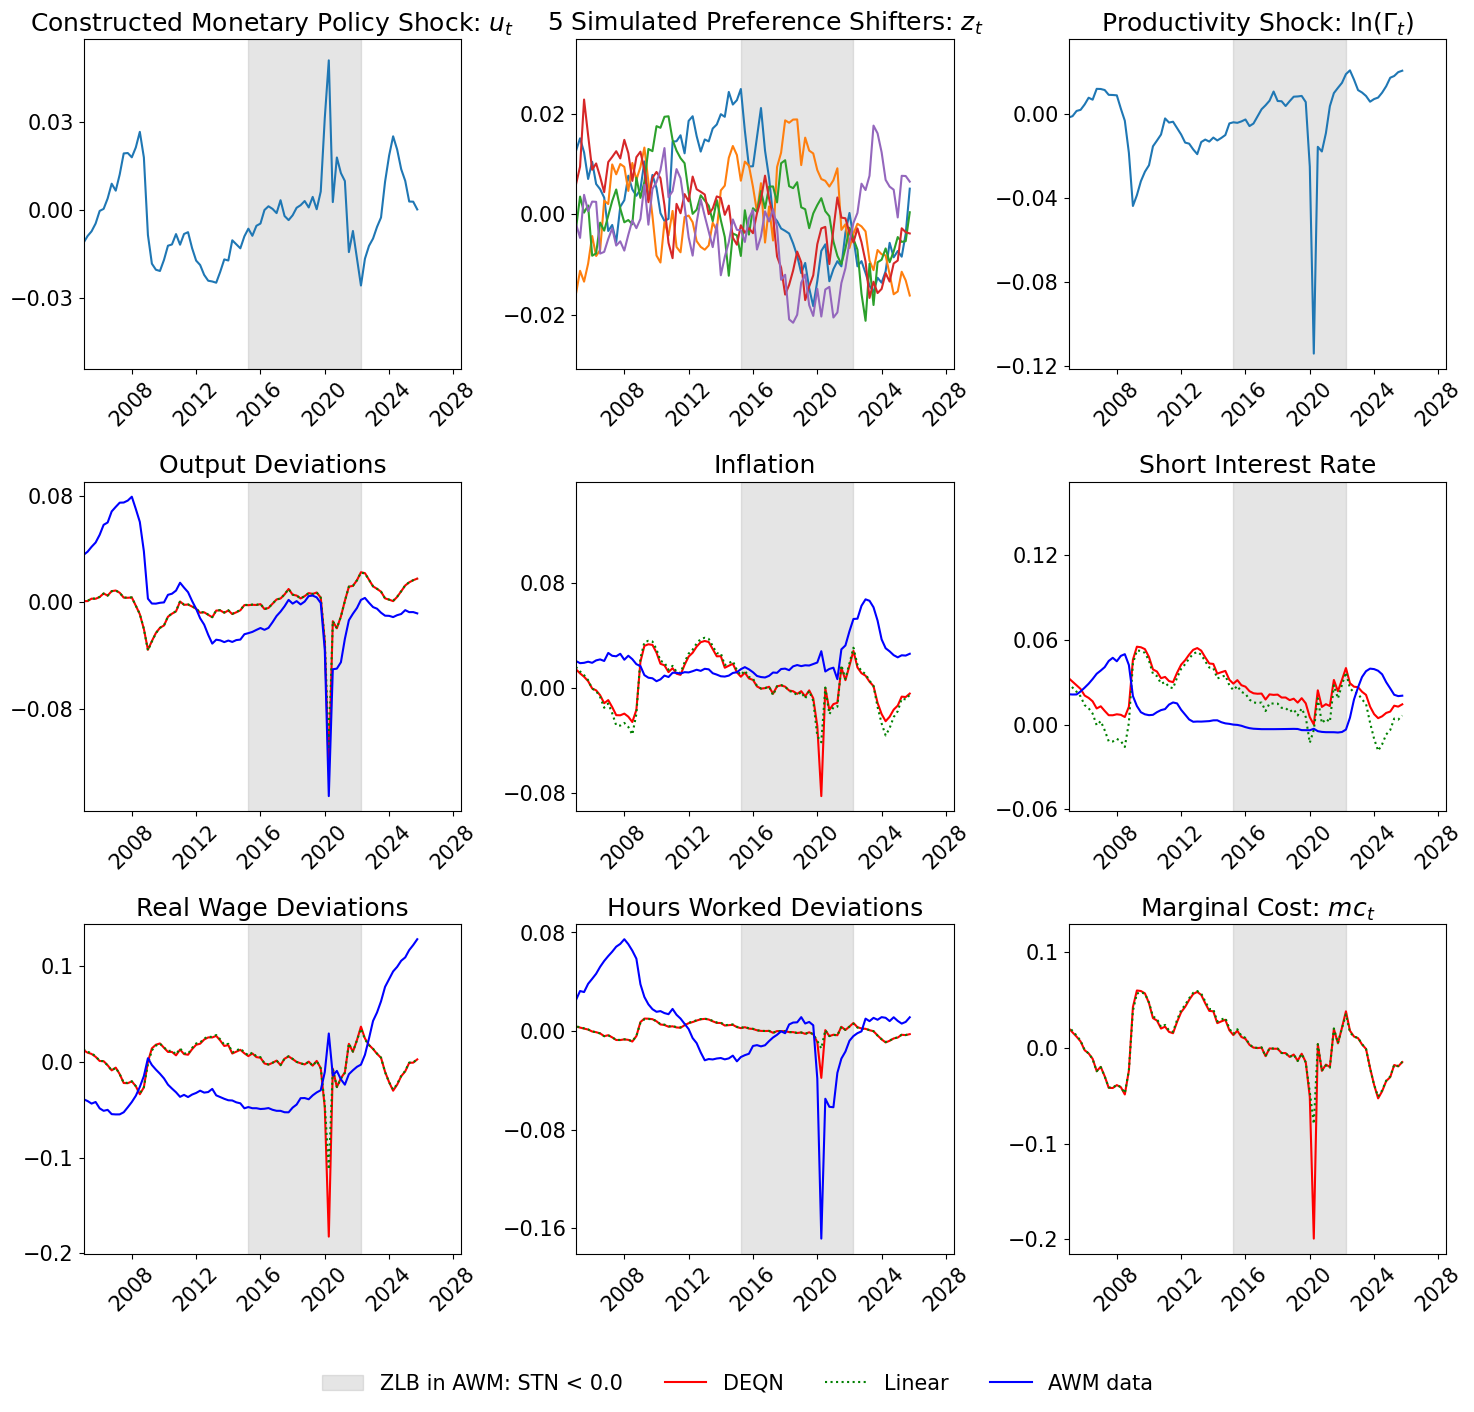

In [17]:
f, ax = plt.subplots(3,3, figsize=(15,15))

ax[0,0].plot(index, est_states[:,0])
ax[0,1].plot(index, z_integrate.reshape(T, N_z)[:,:5])
ax[0,2].plot(index, est_states[:,2])

ax[0,0].set_title(r'Constructed Monetary Policy Shock: $u_t$')
ax[0,1].set_title(r'5 Simulated Preference Shifters: $z_t$')
ax[0,2].set_title(r'Productivity Shock: $\ln(\Gamma_t)$')

# Række 1
ax[1,0].plot(index, Y, label='DEQN', color='red')
if do_extra: ax[1,0].plot(index, Y_extra, ls='--', label='DEQN w/o ZLB', color='orange')
if do_lin:   ax[1,0].plot(index, Y_lin, ls='dotted', label='Linear', color='green')
if do_OccBin: ax[1,0].plot(index, Y_OccBin, label='OccBin', color='purple')
ax[1,0].plot(index, est_policies[:, 0], label='AWM data', color='blue')
ax[1,0].set_title(r'Output Deviations')

ax[1,1].plot(index, pi, color='red')
if do_extra: ax[1,1].plot(index, pi_extra, ls='--', color='orange')
if do_lin:   ax[1,1].plot(index, pi_lin, ls='dotted', color='green')
if do_OccBin: ax[1,1].plot(index, pi_OccBin, color='purple')
ax[1,1].plot(index, est_policies[:, 1], color='blue')
ax[1,1].set_title(r'Inflation')

ax[1,2].plot(index, i, color='red')
if do_extra: ax[1,2].plot(index, i_extra, ls='--', color='orange')
if do_lin:   ax[1,2].plot(index, i_lin, ls='dotted', color='green')
if do_OccBin: ax[1,2].plot(index, i_OccBin, color='purple')
ax[1,2].plot(index, est_aux_var[:,0]/100, color='blue')
ax[1,2].set_title(r'Short Interest Rate')

# Række 2
ax[2,0].plot(index, w, color='red')
if do_extra: ax[2,0].plot(index, w_extra, ls='--', color='orange')
if do_lin:   ax[2,0].plot(index, w_lin, ls='dotted', color='green')
if do_OccBin: ax[2,0].plot(index, w_OccBin, color='purple')
ax[2,0].plot(index, est_aux_var[:,2], color='blue')
ax[2,0].set_title(r'Real Wage Deviations')

ax[2,1].plot(index, L, color='red')
if do_extra: ax[2,1].plot(index, L_extra, ls='--', color='orange')
if do_lin:   ax[2,1].plot(index, L_lin, ls='dotted', color='green')
if do_OccBin: ax[2,1].plot(index, L_OccBin, color='purple')
ax[2,1].plot(index, est_aux_var[:,1], color='blue')
ax[2,1].set_title(r'Hours Worked Deviations')

ax[2,2].plot(index, mc, color='red')
if do_extra: ax[2,2].plot(index, mc_extra, ls='--', color='orange')
if do_lin:   ax[2,2].plot(index, mc_lin, ls='dotted', color='green')
if do_OccBin: ax[2,2].plot(index, mc_OccBin, color='purple')
ax[2,2].set_title('Marginal Cost: ${mc}_t$')

# --- Resten af din kode (formatering, skygge og legende) er uændret ---
for subplot in ax.flat:
    subplot.set_xlim(left=pd.Timestamp('2005-01-01'))

zlb_mask = est_aux_var[:,0]/100 < 0
label_add = True
for i in range(3):
    for j in range(3):
        ax[i,j].yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
        if label_add:
            ax[i,j].fill_between(index, 0, 1, where=zlb_mask, color='gray', alpha=0.2, 
                                 transform=ax[i,j].get_xaxis_transform(), label='ZLB in AWM: STN < 0.0')
            label_add = False
        else:
            ax[i,j].fill_between(index, 0, 1, where=zlb_mask, color='gray', alpha=0.2,
                                 transform=ax[i,j].get_xaxis_transform())

for subplot in ax.flat:
    subplot.tick_params(axis='x', rotation=45)

f.tight_layout(rect=[0, 0.1, 1, 1])
f.legend(loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=5, frameon=False)

In [18]:
L[index == '2020-01-01']

Array([-0.00905901], dtype=float32)

In [19]:
f.savefig('plots/05_25_Model_vs_Data.png')

In [20]:
test_states = est_states.at[:, 1].set(-0.05) # set z = -0.05
test_states = test_states.at[:, 0].set(test_states[:, 0]*1.2)
test_states = test_states.at[:, 2].set(test_states[:, 2]*1.2)

In [21]:
test_states

Array([[ 8.89280345e-04, -5.00000007e-02, -3.86191569e-02],
       [-7.19547132e-03, -5.00000007e-02, -3.40409353e-02],
       [-1.40240754e-03, -5.00000007e-02, -2.00394168e-02],
       [-1.02691529e-02, -5.00000007e-02, -1.85560994e-02],
       [-1.31448554e-02, -5.00000007e-02, -1.01996725e-02],
       [-1.55914770e-02, -5.00000007e-02, -1.05699645e-02],
       [-1.87679380e-02, -5.00000007e-02, -4.44798917e-03],
       [-6.61595666e-04, -5.00000007e-02,  1.14450615e-03],
       [-1.71367191e-02, -5.00000007e-02,  1.22292014e-02],
       [-4.47607832e-03, -5.00000007e-02,  1.30286431e-02],
       [ 3.41471680e-03, -5.00000007e-02,  1.70139931e-02],
       [ 4.40454436e-03, -5.00000007e-02,  1.96543187e-02],
       [ 6.37136912e-03, -5.00000007e-02,  2.30085589e-02],
       [-4.40127263e-03, -5.00000007e-02,  1.86764076e-02],
       [-5.83474198e-03, -5.00000007e-02,  2.04048045e-02],
       [-3.07576228e-02, -5.00000007e-02, -3.25335586e-03],
       [-4.52833995e-02, -5.00000007e-02

In [22]:
Y, pi = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, test_states, test_states.shape[0])
i = model_funcs.taylor_rule(model.par, Y, pi, test_states[:, 0], test_states[:, 1], test_states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

(np.float64(12784.0), np.float64(21361.85))

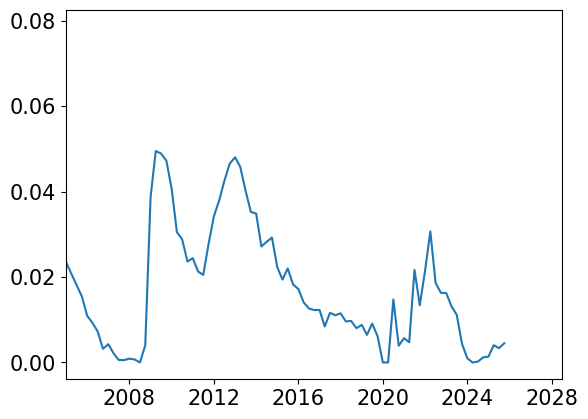

In [23]:
plt.plot(index, i)
plt.xlim(left=pd.Timestamp('2005-01-01'))